# Notebook 04 · Modelado y Comparativa — OLIST Brasil
**Seminario EDA 2026 · Caso 09**

Objetivo: entrenar y comparar múltiples modelos de clasificación para predecir si un pedido llegará tarde (`entrego_tarde`).

Modelos evaluados:
- `LogisticRegression` — baseline interpretable
- `DecisionTreeClassifier` — árbol de decisión, muy explicable
- `RandomForestClassifier` — ensemble robusto
- `GradientBoostingClassifier` — boosting, generalmente el más preciso

Todos usan `class_weight='balanced'` para compensar el desbalance (6.8% tardíos vs 93.2% a tiempo).

## 0. Imports y carga del DataFrame maestro

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

MODELS_DIR = Path('../models')
DOCS_DIR   = Path('../docs')
MODELS_DIR.mkdir(exist_ok=True)
DOCS_DIR.mkdir(exist_ok=True)

df = pd.read_parquet('../data/processed/df_maestro.parquet')
print(f'DataFrame cargado: {len(df):,} filas · {df.shape[1]} columnas')

DataFrame cargado: 110,197 filas · 29 columnas


## 1. Selección de features y preparación de datos

Elegimos las features que el modelo puede conocer **antes** de que el pedido sea entregado — no podemos usar `dias_retraso` porque eso es lo que queremos predecir.

In [18]:
FEATURES = [
    'price',
    'freight_value',
    'product_weight_g',
    'distancia_aprox',
    'dias_despacho',
    'customer_state',
    'seller_state',
    'product_category_name_english',
]
TARGET = 'entrego_tarde'

df_model = df[FEATURES + [TARGET]].dropna().copy()

# Codificar variables categóricas con LabelEncoder
cat_cols = ['customer_state', 'seller_state', 'product_category_name_english']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Filas disponibles para modelado: {len(df_model):,}')
print(f'Features: {FEATURES}')
print(f'\nDistribución del target:')
print(y.value_counts().to_string())
print(f'\nTasa de retraso: {y.mean()*100:.1f}%')

Filas disponibles para modelado: 108,091
Features: ['price', 'freight_value', 'product_weight_g', 'distancia_aprox', 'dias_despacho', 'customer_state', 'seller_state', 'product_category_name_english']

Distribución del target:
entrego_tarde
0    100990
1      7101

Tasa de retraso: 6.6%


## 2. Split train/test

Dividimos en 80% entrenamiento y 20% prueba. `stratify=y` garantiza que la proporción de tardíos sea la misma en ambos conjuntos.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} filas  ({y_train.mean()*100:.1f}% tardíos)')
print(f'Test:  {len(X_test):,} filas  ({y_test.mean()*100:.1f}% tardíos)')

Train: 86,472 filas  (6.6% tardíos)
Test:  21,619 filas  (6.6% tardíos)


## 3. Entrenamiento de los 4 modelos

Todos usan `class_weight='balanced'` para que el modelo preste más atención a los pedidos tardíos (la clase minoritaria).

In [20]:
modelos = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
    ),
}

resultados = {}

for nombre, modelo in modelos.items():
    print(f'Entrenando {nombre}...', end=' ')
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados[nombre] = {
        'modelo': modelo,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }
    print('✓')

print('\nTodos los modelos entrenados.')

Entrenando Logistic Regression... ✓
Entrenando Decision Tree... ✓
Entrenando Random Forest... ✓
Entrenando Gradient Boosting... ✓

Todos los modelos entrenados.


## 4. Tabla comparativa de métricas

- **Precision:** de los que predijo como tardíos, ¿cuántos realmente lo fueron?
- **Recall:** de todos los tardíos reales, ¿cuántos detectó?
- **F1:** balance entre precision y recall — la métrica principal
- **ROC-AUC:** capacidad del modelo de separar las clases (1.0 = perfecto, 0.5 = azar)

In [21]:
tabla = pd.DataFrame({
    nombre: {
        'Accuracy':  f"{r['accuracy']:.3f}",
        'Precision': f"{r['precision']:.3f}",
        'Recall':    f"{r['recall']:.3f}",
        'F1-Score':  f"{r['f1']:.3f}",
        'ROC-AUC':   f"{r['roc_auc']:.3f}",
    }
    for nombre, r in resultados.items()
}).T

print('=' * 75)
print('COMPARATIVA DE MODELOS')
print('=' * 75)
print(tabla.to_string())
print('=' * 75)

mejor = max(resultados, key=lambda k: resultados[k]['recall'])
print(f'\nMejor modelo por Recall: {mejor} ({resultados[mejor]["recall"]:.3f})')

COMPARATIVA DE MODELOS
                    Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression    0.706     0.122  0.558    0.200   0.698
Decision Tree          0.700     0.130  0.625    0.215   0.713
Random Forest          0.943     0.802  0.165    0.274   0.768
Gradient Boosting      0.937     0.689  0.064    0.117   0.747

Mejor modelo por Recall: Decision Tree (0.625)


## 5. Gráfica comparativa

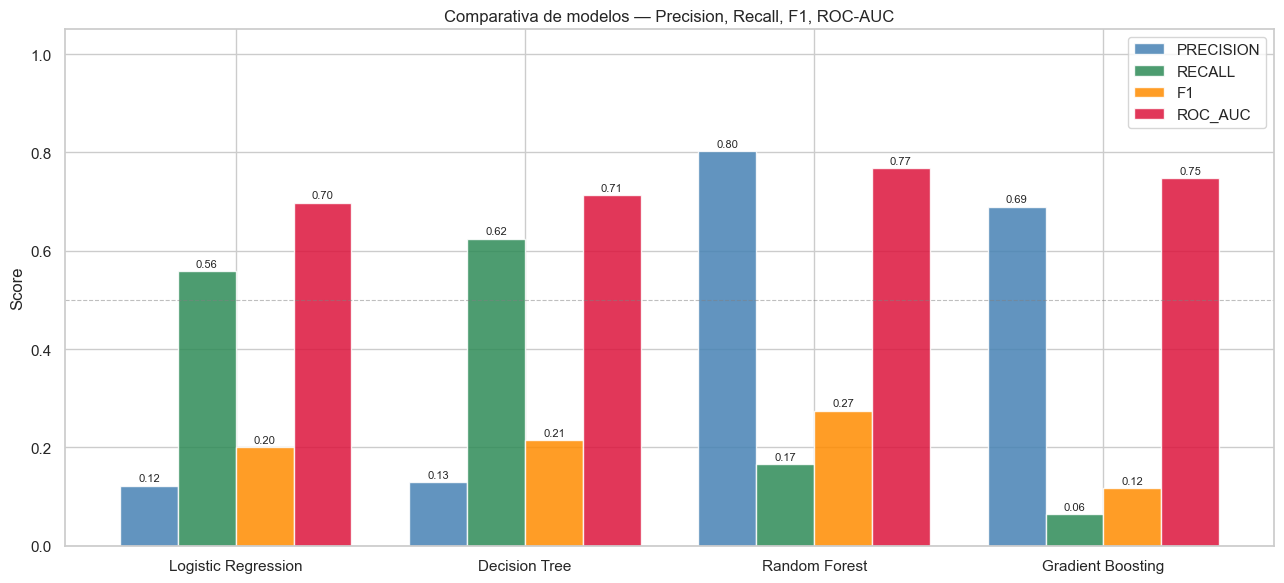

In [22]:
metricas = ['precision', 'recall', 'f1', 'roc_auc']
nombres  = list(resultados.keys())
x = np.arange(len(nombres))
width = 0.2
colores = ['steelblue', 'seagreen', 'darkorange', 'crimson']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metrica, color) in enumerate(zip(metricas, colores)):
    valores = [resultados[n][metrica] for n in nombres]
    bars = ax.bar(x + i * width, valores, width, label=metrica.upper(), color=color, alpha=0.85)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(nombres, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Comparativa de modelos — Precision, Recall, F1, ROC-AUC')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('../docs/fig07_comparativa_modelos.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Matrices de confusión

Muestra cuántos pedidos clasificó correctamente e incorrectamente cada modelo.

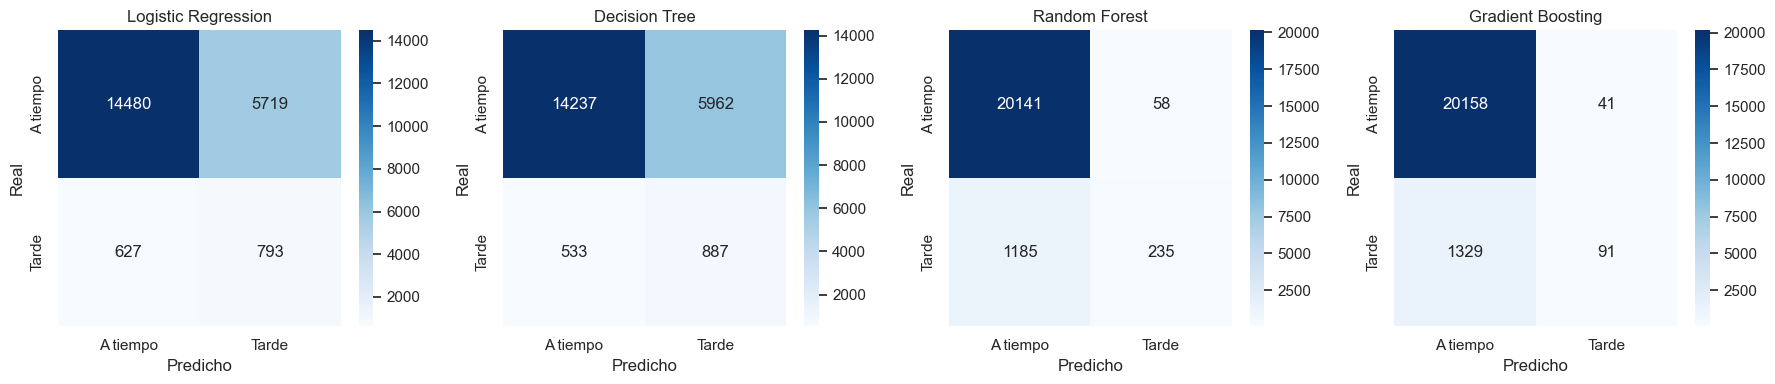

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (nombre, r) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['A tiempo', 'Tarde'],
                yticklabels=['A tiempo', 'Tarde'])
    ax.set_title(nombre)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('../docs/fig08_matrices_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Feature importance del mejor modelo

¿Qué variables fueron las más importantes para predecir el retraso?

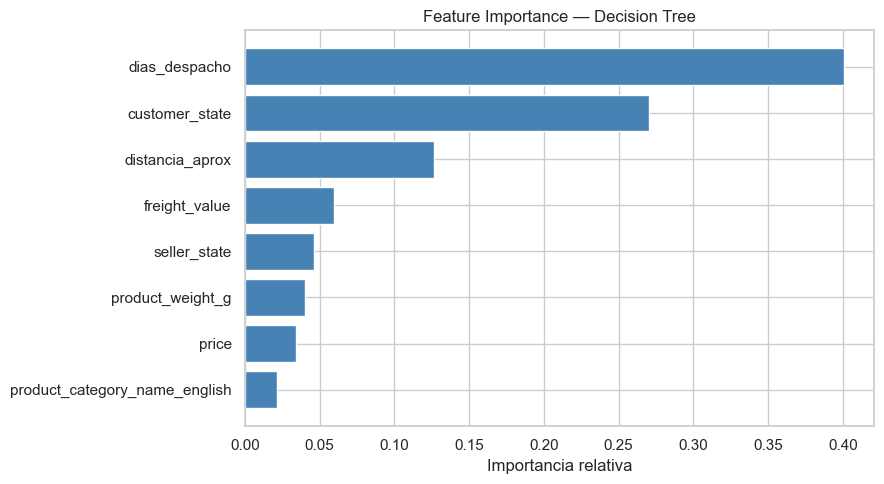

Top 3 variables más importantes:
        feature  importance
distancia_aprox    0.126828
 customer_state    0.270542
  dias_despacho    0.400832


In [24]:
mejor_modelo = resultados[mejor]['modelo']

# Obtener feature importance (Random Forest y Gradient Boosting la tienen directamente)
if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = mejor_modelo.feature_importances_
elif hasattr(mejor_modelo, 'named_steps'):
    importancias = mejor_modelo.named_steps['clf'].coef_[0]
else:
    importancias = np.zeros(len(FEATURES))

fi = pd.DataFrame({
    'feature': FEATURES,
    'importance': np.abs(importancias)
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi['feature'], fi['importance'], color='steelblue', edgecolor='white')
ax.set_title(f'Feature Importance — {mejor}')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('../docs/fig09_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 3 variables más importantes:')
print(fi.tail(3)[['feature', 'importance']].to_string(index=False))

## 8. Serializar el mejor modelo

Guardamos el mejor modelo con `joblib` para usarlo en la API y el dashboard.

In [25]:
output_path = MODELS_DIR / 'mejor_modelo.pkl'
joblib.dump(mejor_modelo, output_path)

print(f'Modelo guardado: {output_path}')
print(f'Modelo elegido: {mejor}')
print(f'  F1-Score:  {resultados[mejor]["f1"]:.3f}')
print(f'  ROC-AUC:   {resultados[mejor]["roc_auc"]:.3f}')
print(f'  Precision: {resultados[mejor]["precision"]:.3f}')
print(f'  Recall:    {resultados[mejor]["recall"]:.3f}')
print()
print('Para cargarlo:')
print('  modelo = joblib.load("../models/mejor_modelo.pkl")')

Modelo guardado: ..\models\mejor_modelo.pkl
Modelo elegido: Decision Tree
  F1-Score:  0.215
  ROC-AUC:   0.713
  Precision: 0.130
  Recall:    0.625

Para cargarlo:
  modelo = joblib.load("../models/mejor_modelo.pkl")


## 9. Justificación de la elección del modelo

Resumen listo para la defensa oral.

In [26]:
print('=' * 60)
print('JUSTIFICACIÓN DE LA ELECCIÓN DEL MODELO')
print('=' * 60)

for nombre, r in resultados.items():
    marca = '★ ELEGIDO' if nombre == mejor else ''
    print(f'\n{nombre} {marca}')
    print(f'  F1={r["f1"]:.3f}  ROC-AUC={r["roc_auc"]:.3f}  '
          f'Precision={r["precision"]:.3f}  Recall={r["recall"]:.3f}')

print()
print('Criterio de selección: Recall')
print('Razón: este es un sistema de ALERTAS de entrega. No detectar')
print('un pedido tardío (falso negativo) es más costoso para el negocio')
print('que generar una falsa alarma (falso positivo). Por eso priorizamos')
print('Recall sobre F1 o Precision — queremos capturar la mayor cantidad')
print('posible de pedidos que realmente llegarán tarde.')
print('=' * 60)

JUSTIFICACIÓN DE LA ELECCIÓN DEL MODELO

Logistic Regression 
  F1=0.200  ROC-AUC=0.698  Precision=0.122  Recall=0.558

Decision Tree ★ ELEGIDO
  F1=0.215  ROC-AUC=0.713  Precision=0.130  Recall=0.625

Random Forest 
  F1=0.274  ROC-AUC=0.768  Precision=0.802  Recall=0.165

Gradient Boosting 
  F1=0.117  ROC-AUC=0.747  Precision=0.689  Recall=0.064

Criterio de selección: Recall
Razón: este es un sistema de ALERTAS de entrega. No detectar
un pedido tardío (falso negativo) es más costoso para el negocio
que generar una falsa alarma (falso positivo). Por eso priorizamos
Recall sobre F1 o Precision — queremos capturar la mayor cantidad
posible de pedidos que realmente llegarán tarde.
